In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing_extensions import TypedDict

load_dotenv()

c:\Users\Ashutosh Pandey\Desktop\Machine Learning\LangGraph-In-Depth\LangGraph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
parent_llm = ChatGroq(model="openai/gpt-oss-20b", temperature=0.2)
sub_llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.3)

In [3]:
class parent_state(TypedDict):
    question: str
    answer_eng: str
    answer_hin: str

In [4]:
def translate_text(state: parent_state):
    prompt = f"""
    
    you are a hindi translate assistnat and you need to just transtat the text coming from answer_eng into hindi
    
    text: {state['answer_eng']}
    
    """
    answer = sub_llm.invoke(prompt).content
    return {'answer_hin': answer}

In [5]:
# graph of sub 
sub = StateGraph(parent_state)

sub.add_node("translate_text", translate_text)

sub.add_edge(START, "translate_text")
sub.add_edge("translate_text", END)

subgraph = sub.compile()

In [6]:
def generate_text(state: parent_state):
    answer = parent_llm.invoke(f"you are a helpful assistant, answer this question {state['question']}").content
    return {'answer_eng': answer}

In [7]:
# parent graph
parent = StateGraph(parent_state)

parent.add_node("generate_text", generate_text)
parent.add_node("translate_text", subgraph)

parent.add_edge(START, "generate_text")
parent.add_edge("generate_text", "translate_text")
parent.add_edge("translate_text", END)

graph = parent.compile()

In [8]:
graph.invoke({"question": "write a 10 line para for assassins creed shadows game"})

{'question': 'write a 10 line para for assassins creed shadows game',
 'answer_eng': 'Assassin’s Creed: Shadows is a thrilling action‑adventure that plunges players into the heart of Renaissance Italy, where intrigue and betrayal lurk behind every cobblestone.  \nSet in the bustling streets of Florence, the game follows the enigmatic protagonist, Aurelia, as she navigates a labyrinth of political factions vying for power.  \nWith a fluid parkour system, players can glide across rooftops, scale ancient cathedrals, and slip through hidden alleyways, all while maintaining the stealthy grace of a true assassin.  \nThe narrative weaves together rich historical detail and compelling myth, revealing how the Order’s ancient secrets intersect with the rise of the Medici dynasty.  \nCombat is dynamic, blending swift swordplay with cunning use of the environment, allowing players to dispatch enemies with style and precision.  \nA unique “Shadow Cloak” mechanic lets Aurelia temporarily vanish into

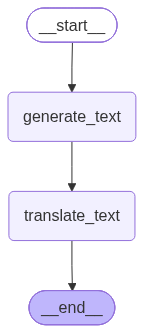

In [10]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())